## 06 - Retrieval Evaluation: Image ↔ Gene Alignment

This notebook evaluates the trained HistoGeneAlign contrastive latent space.

Input:

    data/embeddings/TENX95_resnet50_contrastive_image_latents_qc.npy
    data/embeddings/TENX95_resnet50_contrastive_gene_latents_qc.npy
    data/embeddings/TENX95_contrastive_qc_metadata_with_splits.csv

Evaluation:

    Image → Gene retrieval
    Gene → Image retrieval

Metrics:

    Recall@1
    Recall@5
    Recall@10
    Median Rank
    Mean Rank
    MRR

Figures:

    Recall@K bar chart
    Rank distribution
    Similarity matrix heatmap
    PCA visualization of aligned latents
    Spatial map of retrieval success/failure

In [1]:
# ============================================================
# Imports, paths, and device setup
# ============================================================

from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# Robust project-root detection
# ------------------------------------------------------------

def find_project_root(start_path=None):
    start_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    if start_path.name == "notebooks":
        return start_path.parent

    return start_path


PROJECT_ROOT = find_project_root()

SAMPLE_ID = "TENX95"

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Notebook 05 output paths
# ------------------------------------------------------------

IMAGE_LATENT_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_contrastive_image_latents_qc.npy"
GENE_LATENT_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_contrastive_gene_latents_qc.npy"
LATENT_METADATA_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_contrastive_qc_metadata_with_splits.csv"

NOTEBOOK05_TEST_METRICS_PATH = METRICS_DIR / f"{SAMPLE_ID}_contrastive_final_test_metrics.json"


# ------------------------------------------------------------
# Notebook 06 output paths
# ------------------------------------------------------------

RETRIEVAL_METRICS_CSV_PATH = METRICS_DIR / f"{SAMPLE_ID}_retrieval_metrics_by_split.csv"
RETRIEVAL_METRICS_JSON_PATH = METRICS_DIR / f"{SAMPLE_ID}_retrieval_metrics_by_split.json"

TEST_I2G_EXAMPLES_PATH = METRICS_DIR / f"{SAMPLE_ID}_test_image_to_gene_retrieval_examples.csv"
TEST_G2I_EXAMPLES_PATH = METRICS_DIR / f"{SAMPLE_ID}_test_gene_to_image_retrieval_examples.csv"

RECALL_BAR_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_retrieval_recall_bar.png"
RANK_DIST_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_test_rank_distribution.png"
SIMILARITY_HEATMAP_PATH = FIGURE_DIR / f"{SAMPLE_ID}_test_similarity_heatmap.png"
PCA_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_contrastive_latent_pca.png"
SPATIAL_SUCCESS_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_test_spatial_top1_success.png"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nInput files:")
for p in [IMAGE_LATENT_PATH, GENE_LATENT_PATH, LATENT_METADATA_PATH]:
    print(p, "| exists:", p.exists())

Project root: c:\Users\Hareen\Desktop\HistoGeneAlign
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Input files:
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_image_latents_qc.npy | exists: True
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_gene_latents_qc.npy | exists: True
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_contrastive_qc_metadata_with_splits.csv | exists: True


In [2]:
# ============================================================
# Load contrastive latent embeddings and metadata
# ============================================================

assert IMAGE_LATENT_PATH.exists(), f"Missing file: {IMAGE_LATENT_PATH}"
assert GENE_LATENT_PATH.exists(), f"Missing file: {GENE_LATENT_PATH}"
assert LATENT_METADATA_PATH.exists(), f"Missing file: {LATENT_METADATA_PATH}"

image_latents = np.load(IMAGE_LATENT_PATH).astype(np.float32)
gene_latents = np.load(GENE_LATENT_PATH).astype(np.float32)
metadata = pd.read_csv(LATENT_METADATA_PATH)

print("Image latents:", image_latents.shape, image_latents.dtype)
print("Gene latents:", gene_latents.shape, gene_latents.dtype)
print("Metadata:", metadata.shape)

assert image_latents.ndim == 2
assert gene_latents.ndim == 2
assert image_latents.shape == gene_latents.shape
assert image_latents.shape[0] == len(metadata)
assert np.isfinite(image_latents).all()
assert np.isfinite(gene_latents).all()

required_cols = [
    "spot_id",
    "patch_index",
    "ann_data_row",
    "embedding_row",
    "embedding_row_full",
    "split",
    "x",
    "y",
]

for col in required_cols:
    assert col in metadata.columns, f"Missing metadata column: {col}"

assert metadata["spot_id"].is_unique
assert metadata["patch_index"].is_unique
assert metadata["ann_data_row"].is_unique

print("\nSplit counts:")
display(metadata["split"].value_counts().rename_axis("split").reset_index(name="n"))

print("\nMetadata preview:")
display(metadata.head())

Image latents: (7530, 256) float32
Gene latents: (7530, 256) float32
Metadata: (7530, 20)

Split counts:


,split,n
0,train,5271
1,test,1130
2,val,1129



Metadata preview:


,embedding_row,sample_id,spot_id,patch_index,ann_data_row,x,y,patch_x,patch_y,library_size,detected_genes,valid_patch,valid_expression,encoder,embedding_dim,embedding_row_full,split,contrastive_embedding_row,projection_dim,contrastive_model
0,0,TENX95,006x022,0,640,10602.456959,3087.342422,10339,2824,1006,177,True,True,resnet50_imagenet_v2,2048,0,test,0,256,resnet50_frozen_gene_mlp_contrastive_baseline
1,1,TENX95,006x023,1,641,11073.045194,3087.342422,10810,2824,1219,239,True,True,resnet50_imagenet_v2,2048,1,train,1,256,resnet50_frozen_gene_mlp_contrastive_baseline
2,2,TENX95,006x024,2,642,11543.633429,3087.342422,11280,2824,5068,283,True,True,resnet50_imagenet_v2,2048,2,train,2,256,resnet50_frozen_gene_mlp_contrastive_baseline
3,3,TENX95,006x025,3,643,12014.221664,3087.342422,11751,2824,6534,299,True,True,resnet50_imagenet_v2,2048,3,train,3,256,resnet50_frozen_gene_mlp_contrastive_baseline
4,4,TENX95,006x026,4,644,12484.809900,3087.342422,12221,2824,3516,272,True,True,resnet50_imagenet_v2,2048,4,train,4,256,resnet50_frozen_gene_mlp_contrastive_baseline


In [3]:
# ============================================================
# Normalize latents and inspect vector norms
#
# The model should already output normalized latents, but I am
# normalizing again here to make cosine retrieval explicit.
# ============================================================

def l2_normalize_np(x, eps=1e-12):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)


image_norms_before = np.linalg.norm(image_latents, axis=1)
gene_norms_before = np.linalg.norm(gene_latents, axis=1)

image_latents_norm = l2_normalize_np(image_latents).astype(np.float32)
gene_latents_norm = l2_normalize_np(gene_latents).astype(np.float32)

image_norms_after = np.linalg.norm(image_latents_norm, axis=1)
gene_norms_after = np.linalg.norm(gene_latents_norm, axis=1)

print("Image latent norms before normalization")
print("min:", image_norms_before.min(), "mean:", image_norms_before.mean(), "max:", image_norms_before.max())

print("\nGene latent norms before normalization")
print("min:", gene_norms_before.min(), "mean:", gene_norms_before.mean(), "max:", gene_norms_before.max())

print("\nImage latent norms after normalization")
print("min:", image_norms_after.min(), "mean:", image_norms_after.mean(), "max:", image_norms_after.max())

print("\nGene latent norms after normalization")
print("min:", gene_norms_after.min(), "mean:", gene_norms_after.mean(), "max:", gene_norms_after.max())

assert np.allclose(image_norms_after, 1.0, atol=1e-5)
assert np.allclose(gene_norms_after, 1.0, atol=1e-5)

Image latent norms before normalization
min: 0.9999999 mean: 1.0 max: 1.0000001

Gene latent norms before normalization
min: 0.9999998 mean: 1.0 max: 1.0000001

Image latent norms after normalization
min: 0.9999999 mean: 1.0 max: 1.0000001

Gene latent norms after normalization
min: 0.9999999 mean: 1.0 max: 1.0000001


In [4]:
# ============================================================
# Retrieval metric functions
#
# Matching convention:
#   image_latents[i] should retrieve gene_latents[i]
#   gene_latents[i] should retrieve image_latents[i]
# ============================================================

def compute_ranks_blockwise(query_vectors, gallery_vectors, block_size=512, device=None):
    """
    Computes exact retrieval ranks without storing the full N x N matrix.

    query_vectors:  N x D
    gallery_vectors: N x D

    Correct match for query i is gallery i.
    Rank = 1 + number of gallery items with higher similarity than true match.
    """
    assert query_vectors.shape == gallery_vectors.shape

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    query_tensor = torch.from_numpy(query_vectors).float().to(device)
    gallery_tensor = torch.from_numpy(gallery_vectors).float().to(device)

    n = query_tensor.shape[0]
    ranks = np.empty(n, dtype=np.int64)
    top1_indices = np.empty(n, dtype=np.int64)
    top1_scores = np.empty(n, dtype=np.float32)
    true_scores = np.empty(n, dtype=np.float32)

    gallery_t = gallery_tensor.T

    for start in range(0, n, block_size):
        end = min(start + block_size, n)

        q = query_tensor[start:end]
        sims = q @ gallery_t

        local_rows = torch.arange(end - start, device=device)
        true_cols = torch.arange(start, end, device=device)

        batch_true_scores = sims[local_rows, true_cols]
        batch_ranks = 1 + (sims > batch_true_scores[:, None]).sum(dim=1)

        batch_top_scores, batch_top_indices = torch.max(sims, dim=1)

        ranks[start:end] = batch_ranks.detach().cpu().numpy()
        top1_indices[start:end] = batch_top_indices.detach().cpu().numpy()
        top1_scores[start:end] = batch_top_scores.detach().cpu().numpy()
        true_scores[start:end] = batch_true_scores.detach().cpu().numpy()

    return ranks, top1_indices, top1_scores, true_scores


def metrics_from_ranks(ranks):
    ranks = np.asarray(ranks)

    metrics = {
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "Recall@50": float(np.mean(ranks <= 50)),
        "MedianRank": float(np.median(ranks)),
        "MeanRank": float(np.mean(ranks)),
        "MRR": float(np.mean(1.0 / ranks)),
    }

    return metrics


def evaluate_split(split_name, image_matrix, gene_matrix, metadata_df, block_size=512):
    split_mask = metadata_df["split"].astype(str).to_numpy() == split_name
    split_indices = np.where(split_mask)[0]

    split_image = image_matrix[split_indices]
    split_gene = gene_matrix[split_indices]

    print(f"\nEvaluating split: {split_name}")
    print("Rows:", len(split_indices))

    i2g_ranks, i2g_top1, i2g_top1_scores, i2g_true_scores = compute_ranks_blockwise(
        query_vectors=split_image,
        gallery_vectors=split_gene,
        block_size=block_size,
        device=device,
    )

    g2i_ranks, g2i_top1, g2i_top1_scores, g2i_true_scores = compute_ranks_blockwise(
        query_vectors=split_gene,
        gallery_vectors=split_image,
        block_size=block_size,
        device=device,
    )

    i2g_metrics = metrics_from_ranks(i2g_ranks)
    g2i_metrics = metrics_from_ranks(g2i_ranks)

    row = {
        "split": split_name,
        "n": int(len(split_indices)),
        "random_Recall@1": float(1.0 / len(split_indices)),
        "random_Recall@5": float(min(5 / len(split_indices), 1.0)),
        "random_Recall@10": float(min(10 / len(split_indices), 1.0)),
    }

    for k, v in i2g_metrics.items():
        row[f"image_to_gene_{k}"] = v

    for k, v in g2i_metrics.items():
        row[f"gene_to_image_{k}"] = v

    row["mean_Recall@1"] = 0.5 * (
        row["image_to_gene_Recall@1"] + row["gene_to_image_Recall@1"]
    )
    row["mean_Recall@5"] = 0.5 * (
        row["image_to_gene_Recall@5"] + row["gene_to_image_Recall@5"]
    )
    row["mean_Recall@10"] = 0.5 * (
        row["image_to_gene_Recall@10"] + row["gene_to_image_Recall@10"]
    )
    row["mean_MRR"] = 0.5 * (
        row["image_to_gene_MRR"] + row["gene_to_image_MRR"]
    )

    details = {
        "split_indices": split_indices,
        "i2g_ranks": i2g_ranks,
        "i2g_top1": i2g_top1,
        "i2g_top1_scores": i2g_top1_scores,
        "i2g_true_scores": i2g_true_scores,
        "g2i_ranks": g2i_ranks,
        "g2i_top1": g2i_top1,
        "g2i_top1_scores": g2i_top1_scores,
        "g2i_true_scores": g2i_true_scores,
    }

    return row, details


print("Retrieval metric functions are ready.")

Retrieval metric functions are ready.


In [6]:
# ============================================================
# Evaluating retrieval on each split
# ============================================================

split_order = ["train", "val", "test"]

retrieval_rows = []
retrieval_details = {}

for split_name in split_order:
    row, details = evaluate_split(
        split_name=split_name,
        image_matrix=image_latents_norm,
        gene_matrix=gene_latents_norm,
        metadata_df=metadata,
        block_size=512,
    )

    retrieval_rows.append(row)
    retrieval_details[split_name] = details

retrieval_metrics_df = pd.DataFrame(retrieval_rows)

display(retrieval_metrics_df)

retrieval_metrics_df.to_csv(RETRIEVAL_METRICS_CSV_PATH, index=False)

with open(RETRIEVAL_METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(retrieval_rows, f, indent=2)

print("Saved retrieval metrics CSV:", RETRIEVAL_METRICS_CSV_PATH)
print("Saved retrieval metrics JSON:", RETRIEVAL_METRICS_JSON_PATH)


Evaluating split: train
Rows: 5271

Evaluating split: val
Rows: 1129

Evaluating split: test
Rows: 1130


,split,n,random_Recall@1,random_Recall@5,random_Recall@10,image_to_gene_Recall@1,image_to_gene_Recall@5,image_to_gene_Recall@10,image_to_gene_Recall@50,image_to_gene_MedianRank,...,gene_to_image_Recall@5,gene_to_image_Recall@10,gene_to_image_Recall@50,gene_to_image_MedianRank,gene_to_image_MeanRank,gene_to_image_MRR,mean_Recall@1,mean_Recall@5,mean_Recall@10,mean_MRR
0,train,5271,0.000190,0.000949,0.001897,0.948587,0.993929,0.997723,1.000000,1.0,...,0.993550,0.998293,1.000000,1.0,1.137545,0.963911,0.944508,0.993739,0.998008,0.966403
1,val,1129,0.000886,0.004429,0.008857,0.095660,0.255979,0.389725,0.741364,17.0,...,0.271036,0.393268,0.740478,16.0,54.037201,0.188039,0.093888,0.263508,0.391497,0.188088
2,test,1130,0.000885,0.004425,0.008850,0.085841,0.292920,0.415044,0.706195,17.0,...,0.274336,0.384071,0.710619,17.0,60.036283,0.185994,0.085841,0.283628,0.399558,0.188041


Saved retrieval metrics CSV: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_retrieval_metrics_by_split.csv
Saved retrieval metrics JSON: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_retrieval_metrics_by_split.json


In [7]:
# ============================================================
# Comparing with Notebook 05 final test metrics
# ============================================================

if NOTEBOOK05_TEST_METRICS_PATH.exists():
    with open(NOTEBOOK05_TEST_METRICS_PATH, "r", encoding="utf-8") as f:
        notebook05_test_metrics = json.load(f)

    print("Notebook 05 final test metrics:")
    print(json.dumps(notebook05_test_metrics, indent=2))

    print("\nNotebook 06 recomputed test metrics:")
    test_row = retrieval_metrics_df[retrieval_metrics_df["split"] == "test"].iloc[0].to_dict()
    print(json.dumps(test_row, indent=2))
else:
    print("Notebook 05 final test metrics file not found.")
    print("This is not fatal because Notebook 06 recomputed metrics from saved latents.")

Notebook 05 final test metrics:
{
  "sample_id": "TENX95",
  "image_encoder": "resnet50_imagenet1k_v2_frozen",
  "best_epoch": 17,
  "test_loss": 1.9760591201022664,
  "image_to_gene_R@1": 0.08584070950746536,
  "image_to_gene_R@5": 0.2929203510284424,
  "image_to_gene_R@10": 0.41504424810409546,
  "image_to_gene_MedianRank": 17.0,
  "image_to_gene_MeanRank": 61.44955825805664,
  "image_to_gene_MRR": 0.19008870422840118,
  "gene_to_image_R@1": 0.08584070950746536,
  "gene_to_image_R@5": 0.2743362784385681,
  "gene_to_image_R@10": 0.3840707838535309,
  "gene_to_image_MedianRank": 17.0,
  "gene_to_image_MeanRank": 60.03628158569336,
  "gene_to_image_MRR": 0.1859935224056244,
  "mean_R@1": 0.08584070950746536,
  "mean_R@5": 0.28362831473350525,
  "mean_R@10": 0.39955751597881317
}

Notebook 06 recomputed test metrics:
{
  "split": "test",
  "n": 1130,
  "random_Recall@1": 0.0008849557522123894,
  "random_Recall@5": 0.004424778761061947,
  "random_Recall@10": 0.008849557522123894,
  "image

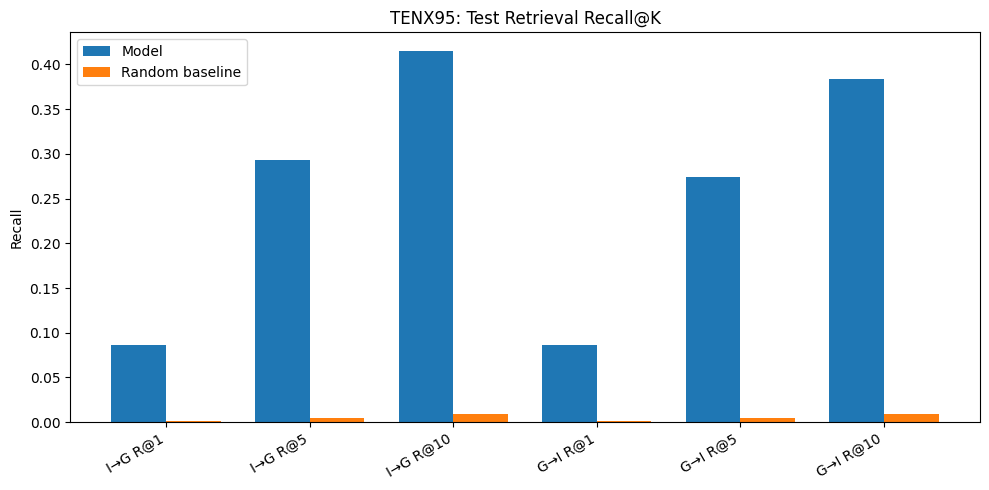

Saved Recall@K figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_retrieval_recall_bar.png


In [8]:
# ============================================================
# Plotting Recall@K bar chart for the test split
# ============================================================

test_metrics = retrieval_metrics_df[retrieval_metrics_df["split"] == "test"].iloc[0]

labels = [
    "I→G R@1",
    "I→G R@5",
    "I→G R@10",
    "G→I R@1",
    "G→I R@5",
    "G→I R@10",
]

values = [
    test_metrics["image_to_gene_Recall@1"],
    test_metrics["image_to_gene_Recall@5"],
    test_metrics["image_to_gene_Recall@10"],
    test_metrics["gene_to_image_Recall@1"],
    test_metrics["gene_to_image_Recall@5"],
    test_metrics["gene_to_image_Recall@10"],
]

random_values = [
    test_metrics["random_Recall@1"],
    test_metrics["random_Recall@5"],
    test_metrics["random_Recall@10"],
    test_metrics["random_Recall@1"],
    test_metrics["random_Recall@5"],
    test_metrics["random_Recall@10"],
]

x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, values, width, label="Model")
plt.bar(x + width / 2, random_values, width, label="Random baseline")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Recall")
plt.title(f"{SAMPLE_ID}: Test Retrieval Recall@K")
plt.legend()
plt.tight_layout()
plt.savefig(RECALL_BAR_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Recall@K figure:", RECALL_BAR_FIG_PATH)

This plot shows the first real evidence that my HistoGeneAlign model is learning a meaningful relationship between **H&E histology morphology** and **spatial transcriptomics gene-expression profiles**.

The blue bars represent my trained contrastive model, while the orange bars represent the random retrieval baseline. Across every retrieval metric, the model performs far above random chance.

This matters because the task is not simple classification. I am not asking the model to predict one label from an image. Instead, I am training a multimodal retrieval system where:

```text
H&E image patch embedding ↔ gene-expression embedding

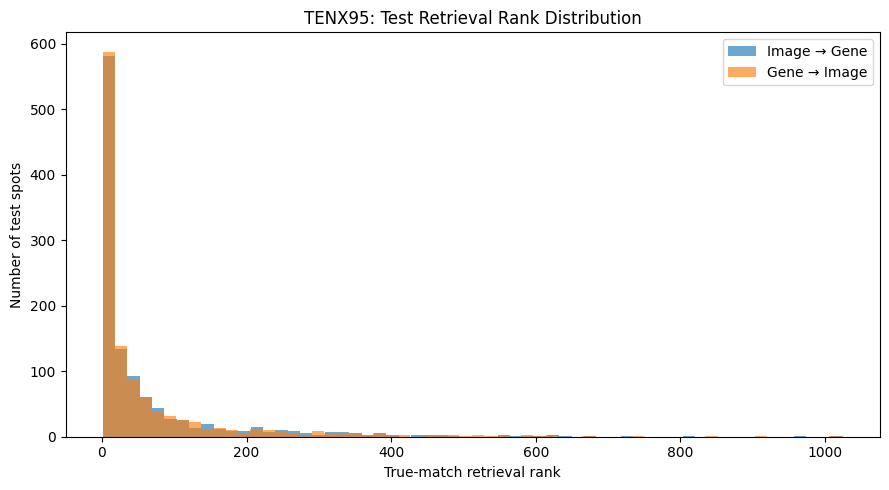

Saved rank distribution figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_test_rank_distribution.png
Image → Gene rank summary:
count    1130.000000
mean       61.449558
std       111.169711
min         1.000000
25%         4.000000
50%        17.000000
75%        62.000000
max      1025.000000
dtype: float64

Gene → Image rank summary:
count    1130.000000
mean       60.036283
std       109.247663
min         1.000000
25%         5.000000
50%        17.000000
75%        61.000000
max      1022.000000
dtype: float64


In [9]:
# ============================================================
# Plotting rank distributions for the test split
# ============================================================

test_details = retrieval_details["test"]

i2g_ranks = test_details["i2g_ranks"]
g2i_ranks = test_details["g2i_ranks"]

plt.figure(figsize=(9, 5))
plt.hist(i2g_ranks, bins=60, alpha=0.65, label="Image → Gene")
plt.hist(g2i_ranks, bins=60, alpha=0.65, label="Gene → Image")
plt.xlabel("True-match retrieval rank")
plt.ylabel("Number of test spots")
plt.title(f"{SAMPLE_ID}: Test Retrieval Rank Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(RANK_DIST_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved rank distribution figure:", RANK_DIST_FIG_PATH)

print("Image → Gene rank summary:")
print(pd.Series(i2g_ranks).describe())

print("\nGene → Image rank summary:")
print(pd.Series(g2i_ranks).describe())

This plot gives me a deeper view of the retrieval performance beyond Recall@K.

Instead of only asking whether the correct match is in the top 1, top 5, or top 10, this plot shows the full distribution of the true-match retrieval rank for every test spot.

In simple terms:

    Lower rank = better retrieval
    Rank 1 = perfect top-1 retrieval
    Rank 10 = correct match appears in top 10
    Rank 100 = correct match is still relatively close
    High rank = poor retrieval

The main observation is that most true matches are concentrated near the left side of the plot, meaning the model usually ranks the correct image–gene pair near the top of the candidate list.

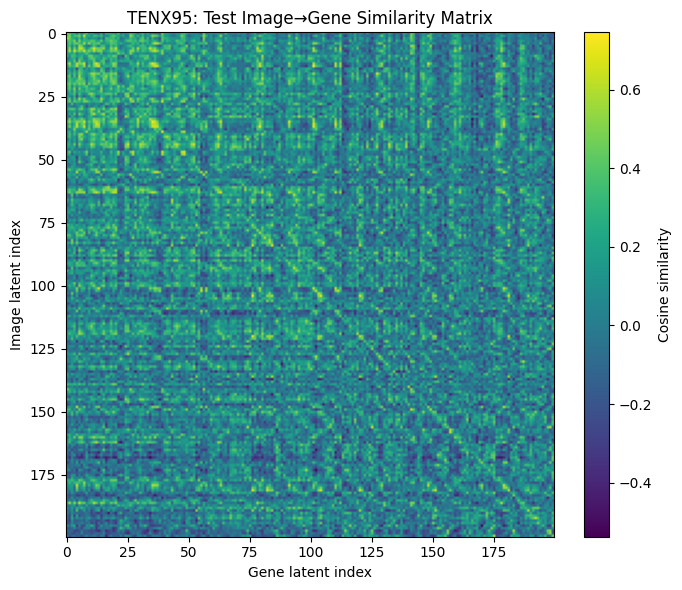

Saved similarity heatmap: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_test_similarity_heatmap.png
Diagonal mean similarity: 0.36392223834991455
Off-diagonal mean similarity: 0.056582290679216385
Diagonal minus off-diagonal: 0.30733993649482727


In [10]:
# ============================================================
# Similarity matrix heatmap for a subset of test spots
#
# A strong aligned model should show stronger diagonal structure.
# ============================================================

test_indices = retrieval_details["test"]["split_indices"]

N_HEATMAP = min(200, len(test_indices))

heatmap_indices = test_indices[:N_HEATMAP]

heatmap_image = image_latents_norm[heatmap_indices]
heatmap_gene = gene_latents_norm[heatmap_indices]

similarity_matrix = heatmap_image @ heatmap_gene.T

plt.figure(figsize=(7, 6))
plt.imshow(similarity_matrix, aspect="auto")
plt.colorbar(label="Cosine similarity")
plt.xlabel("Gene latent index")
plt.ylabel("Image latent index")
plt.title(f"{SAMPLE_ID}: Test Image→Gene Similarity Matrix")
plt.tight_layout()
plt.savefig(SIMILARITY_HEATMAP_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved similarity heatmap:", SIMILARITY_HEATMAP_PATH)

diag_mean = np.diag(similarity_matrix).mean()
off_diag_mean = similarity_matrix[~np.eye(N_HEATMAP, dtype=bool)].mean()

print("Diagonal mean similarity:", float(diag_mean))
print("Off-diagonal mean similarity:", float(off_diag_mean))
print("Diagonal minus off-diagonal:", float(diag_mean - off_diag_mean))

This similarity matrix shows how well my trained HistoGeneAlign model aligns **H&E image embeddings** with **gene-expression embeddings** in the shared contrastive latent space.

Each row represents an H&E image patch latent vector, and each column represents a gene-expression latent vector. The value in each cell is the cosine similarity between one image embedding and one gene embedding.

```text
Higher similarity = the model thinks the image patch and gene profile are more related
Lower similarity  = the model thinks they are less related
```

The statistics mean that the model is giving much higher similarity to the correct image–gene pairs than to unmatched pairs.

That is exactly what I want from a contrastive learning model.

The model has learned to bring matched H&E morphology and spatial transcriptomics profiles closer together in the embedding space, while keeping unrelated image–gene pairs farther apart

In [11]:
# ============================================================
# Build retrieval example tables for test split
# ============================================================

test_indices = retrieval_details["test"]["split_indices"]

test_meta = metadata.iloc[test_indices].reset_index(drop=False)
test_meta = test_meta.rename(columns={"index": "global_row"})

i2g_top1_local = retrieval_details["test"]["i2g_top1"]
g2i_top1_local = retrieval_details["test"]["g2i_top1"]

i2g_ranks = retrieval_details["test"]["i2g_ranks"]
g2i_ranks = retrieval_details["test"]["g2i_ranks"]

i2g_top1_global = test_indices[i2g_top1_local]
g2i_top1_global = test_indices[g2i_top1_local]

i2g_true_scores = retrieval_details["test"]["i2g_true_scores"]
i2g_top1_scores = retrieval_details["test"]["i2g_top1_scores"]

g2i_true_scores = retrieval_details["test"]["g2i_true_scores"]
g2i_top1_scores = retrieval_details["test"]["g2i_top1_scores"]


# ------------------------------------------------------------
# Image → Gene retrieval table
# ------------------------------------------------------------

i2g_examples = pd.DataFrame({
    "query_global_row": test_indices,
    "query_spot_id": metadata.iloc[test_indices]["spot_id"].to_numpy(),
    "retrieved_global_row": i2g_top1_global,
    "retrieved_spot_id": metadata.iloc[i2g_top1_global]["spot_id"].to_numpy(),
    "true_rank": i2g_ranks,
    "true_similarity": i2g_true_scores,
    "top1_similarity": i2g_top1_scores,
    "top1_correct": i2g_ranks == 1,
    "query_x": metadata.iloc[test_indices]["x"].to_numpy(),
    "query_y": metadata.iloc[test_indices]["y"].to_numpy(),
    "retrieved_x": metadata.iloc[i2g_top1_global]["x"].to_numpy(),
    "retrieved_y": metadata.iloc[i2g_top1_global]["y"].to_numpy(),
})

i2g_examples["spatial_distance_to_top1"] = np.sqrt(
    (i2g_examples["query_x"] - i2g_examples["retrieved_x"]) ** 2
    + (i2g_examples["query_y"] - i2g_examples["retrieved_y"]) ** 2
)


# ------------------------------------------------------------
# Gene → Image retrieval table
# ------------------------------------------------------------

g2i_examples = pd.DataFrame({
    "query_global_row": test_indices,
    "query_spot_id": metadata.iloc[test_indices]["spot_id"].to_numpy(),
    "retrieved_global_row": g2i_top1_global,
    "retrieved_spot_id": metadata.iloc[g2i_top1_global]["spot_id"].to_numpy(),
    "true_rank": g2i_ranks,
    "true_similarity": g2i_true_scores,
    "top1_similarity": g2i_top1_scores,
    "top1_correct": g2i_ranks == 1,
    "query_x": metadata.iloc[test_indices]["x"].to_numpy(),
    "query_y": metadata.iloc[test_indices]["y"].to_numpy(),
    "retrieved_x": metadata.iloc[g2i_top1_global]["x"].to_numpy(),
    "retrieved_y": metadata.iloc[g2i_top1_global]["y"].to_numpy(),
})

g2i_examples["spatial_distance_to_top1"] = np.sqrt(
    (g2i_examples["query_x"] - g2i_examples["retrieved_x"]) ** 2
    + (g2i_examples["query_y"] - g2i_examples["retrieved_y"]) ** 2
)

i2g_examples.to_csv(TEST_I2G_EXAMPLES_PATH, index=False)
g2i_examples.to_csv(TEST_G2I_EXAMPLES_PATH, index=False)

print("Saved Image→Gene retrieval examples:", TEST_I2G_EXAMPLES_PATH)
print("Saved Gene→Image retrieval examples:", TEST_G2I_EXAMPLES_PATH)

print("\nBest Image→Gene examples:")
display(i2g_examples.sort_values(["true_rank", "spatial_distance_to_top1"]).head(10))

print("\nWorst Image→Gene examples:")
display(i2g_examples.sort_values(["true_rank", "spatial_distance_to_top1"], ascending=[False, False]).head(10))

Saved Image→Gene retrieval examples: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_test_image_to_gene_retrieval_examples.csv
Saved Gene→Image retrieval examples: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_test_gene_to_image_retrieval_examples.csv

Best Image→Gene examples:


,query_global_row,query_spot_id,retrieved_global_row,retrieved_spot_id,true_rank,true_similarity,top1_similarity,top1_correct,query_x,query_y,retrieved_x,retrieved_y,spatial_distance_to_top1
25,122,010x033,122,010x033,1,0.535513,0.535513,True,15778.927547,4969.695363,15778.927547,4969.695363,0.0
26,135,010x046,135,010x046,1,0.593602,0.593602,True,21896.574606,4969.695363,21896.574606,4969.695363,0.0
34,177,011x046,177,011x046,1,0.592787,0.592787,True,21896.574606,5440.283598,21896.574606,5440.283598,0.0
35,179,011x048,179,011x048,1,0.720695,0.720695,True,22837.751076,5440.283598,22837.751076,5440.283598,0.0
63,401,015x061,401,015x061,1,0.651950,0.651950,True,28955.398135,7322.636539,28955.398135,7322.636539,0.0
157,996,024x067,996,024x067,1,0.585012,0.585012,True,31778.927547,11557.930657,31778.927547,11557.930657,0.0
192,1174,027x020,1174,027x020,1,0.616705,0.616705,True,9661.280488,12969.695363,9661.280488,12969.695363,0.0
203,1203,027x049,1203,027x049,1,0.588151,0.588151,True,23308.339311,12969.695363,23308.339311,12969.695363,0.0
238,1414,030x018,1414,030x018,1,0.573068,0.573068,True,8720.104017,14381.460069,8720.104017,14381.460069,0.0
252,1480,030x084,1480,030x084,1,0.731005,0.731005,True,39778.927547,14381.460069,39778.927547,14381.460069,0.0



Worst Image→Gene examples:


,query_global_row,query_spot_id,retrieved_global_row,retrieved_spot_id,true_rank,true_similarity,top1_similarity,top1_correct,query_x,query_y,retrieved_x,retrieved_y,spatial_distance_to_top1
742,4912,078x046,5076,081x023,1025,-0.232477,0.477563,False,21896.574606,36969.695363,11073.045194,38381.460069,10915.212710
420,2638,044x037,2742,045x052,968,-0.170318,0.549109,False,17661.280488,20969.695363,24720.104017,21440.283598,7074.492413
607,4063,061x041,3350,052x050,806,-0.105195,0.490507,False,19543.633429,28969.695363,23778.927547,24734.401245,5989.610382
106,622,019x035,2796,046x019,722,-0.060611,0.541029,False,16720.104017,9204.989481,9190.692253,21910.871833,14769.275131
299,1720,033x071,6478,100x010,672,-0.041370,0.529056,False,33661.280488,15793.224775,4955.398135,47322.636539,42639.553092
133,808,022x021,773,021x054,640,-0.042006,0.516696,False,10131.868723,10616.754186,25661.280488,10146.165951,15536.540253
442,2820,046x043,5011,080x021,631,-0.037355,0.494875,False,20484.809900,21910.871833,10131.868723,37910.871833,19057.371041
139,847,022x060,95,009x041,623,-0.010970,0.474091,False,28484.809900,10616.754186,19543.633429,4499.107128,10833.754761
313,1786,034x048,3187,050x065,610,-0.018480,0.528928,False,22837.751076,16263.813010,30837.751076,23793.224775,10985.992969
595,3971,060x015,4147,063x013,591,-0.026338,0.648553,False,7308.339311,28499.107128,6367.162841,29910.871833,1696.730012


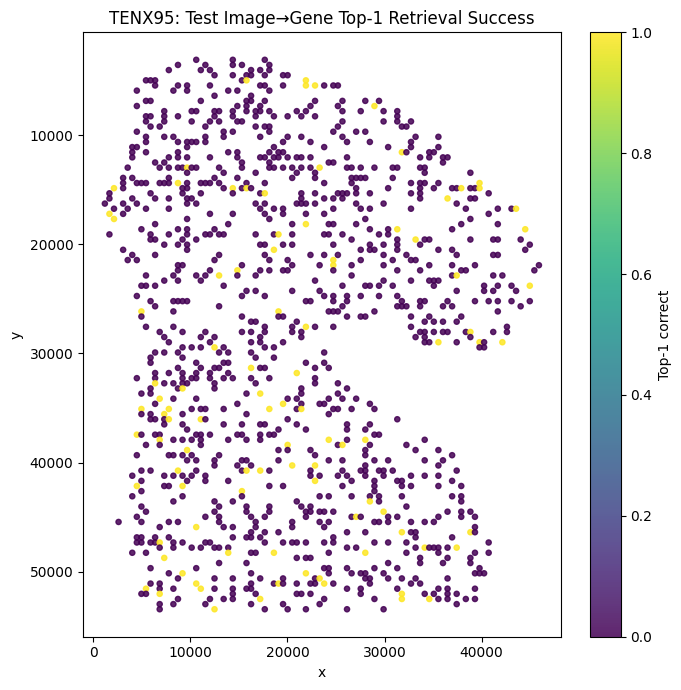

Saved spatial success figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_test_spatial_top1_success.png
Top-1 success rate: 0.08584070796460178
Median top-1 spatial distance, all: 9191.381304314378
Median top-1 spatial distance, failures only: 10833.7547606789


In [12]:
# ============================================================
# Spatial map of test Image→Gene top-1 retrieval success
# ============================================================

spatial_df = i2g_examples.copy()
spatial_df["top1_correct_int"] = spatial_df["top1_correct"].astype(int)

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    spatial_df["query_x"],
    spatial_df["query_y"],
    c=spatial_df["top1_correct_int"],
    s=14,
    alpha=0.85,
)
plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"{SAMPLE_ID}: Test Image→Gene Top-1 Retrieval Success")
plt.colorbar(scatter, label="Top-1 correct")
plt.tight_layout()
plt.savefig(SPATIAL_SUCCESS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved spatial success figure:", SPATIAL_SUCCESS_FIG_PATH)

success_rate = spatial_df["top1_correct"].mean()
median_distance_all = spatial_df["spatial_distance_to_top1"].median()
median_distance_failures = spatial_df.loc[
    ~spatial_df["top1_correct"],
    "spatial_distance_to_top1"
].median()

print("Top-1 success rate:", float(success_rate))
print("Median top-1 spatial distance, all:", float(median_distance_all))
print("Median top-1 spatial distance, failures only:", float(median_distance_failures))

This plot shows where my model succeeds and fails spatially across the TENX95 tissue section for **Image → Gene top-1 retrieval**.

Each dot is a test spot.

    Yellow = the model retrieved the exact matching gene-expression profile at rank 1
    Purple = the exact match was not ranked first

The overall top-1 success rate is:

    Top-1 success rate: 8.58%

At first glance, most points are purple, but that is expected because top-1 retrieval is a very strict metric. The model has to choose the exact matching gene profile out of about 1130 test candidates

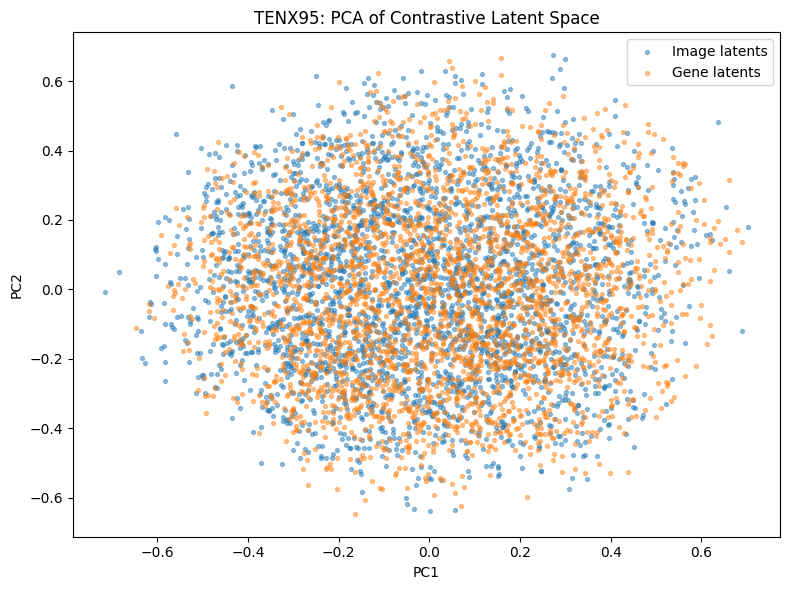

Saved PCA figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_contrastive_latent_pca.png
Explained variance ratio: [0.06795095 0.06203292]


In [13]:
# ============================================================
# PCA visualization of image and gene latents
#
# This shows whether projected image and gene embeddings occupy
# a roughly shared latent space after contrastive training.
# ============================================================

N_PCA = min(3000, len(metadata))

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(metadata), size=N_PCA, replace=False)

combined_latents = np.vstack([
    image_latents_norm[sample_indices],
    gene_latents_norm[sample_indices],
])

modality_labels = np.array(
    ["image"] * N_PCA + ["gene"] * N_PCA
)

pca = PCA(n_components=2, random_state=SEED)
combined_2d = pca.fit_transform(combined_latents)

pca_df = pd.DataFrame({
    "PC1": combined_2d[:, 0],
    "PC2": combined_2d[:, 1],
    "modality": modality_labels,
})

plt.figure(figsize=(8, 6))

image_mask = pca_df["modality"] == "image"
gene_mask = pca_df["modality"] == "gene"

plt.scatter(
    pca_df.loc[image_mask, "PC1"],
    pca_df.loc[image_mask, "PC2"],
    s=8,
    alpha=0.45,
    label="Image latents",
)

plt.scatter(
    pca_df.loc[gene_mask, "PC1"],
    pca_df.loc[gene_mask, "PC2"],
    s=8,
    alpha=0.45,
    label="Gene latents",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"{SAMPLE_ID}: PCA of Contrastive Latent Space")
plt.legend()
plt.tight_layout()
plt.savefig(PCA_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PCA figure:", PCA_FIG_PATH)
print("Explained variance ratio:", pca.explained_variance_ratio_)

This PCA plot shows how the trained HistoGeneAlign model organizes image latents and gene latents after contrastive training.

The blue points are projected H&E image embeddings, and the orange points are projected gene-expression embeddings. Both are shown in the same 2D PCA space.

The key observation is:

    Image latents and gene latents strongly overlap in the same region of latent space.

That is what I want from a contrastive alignment model.

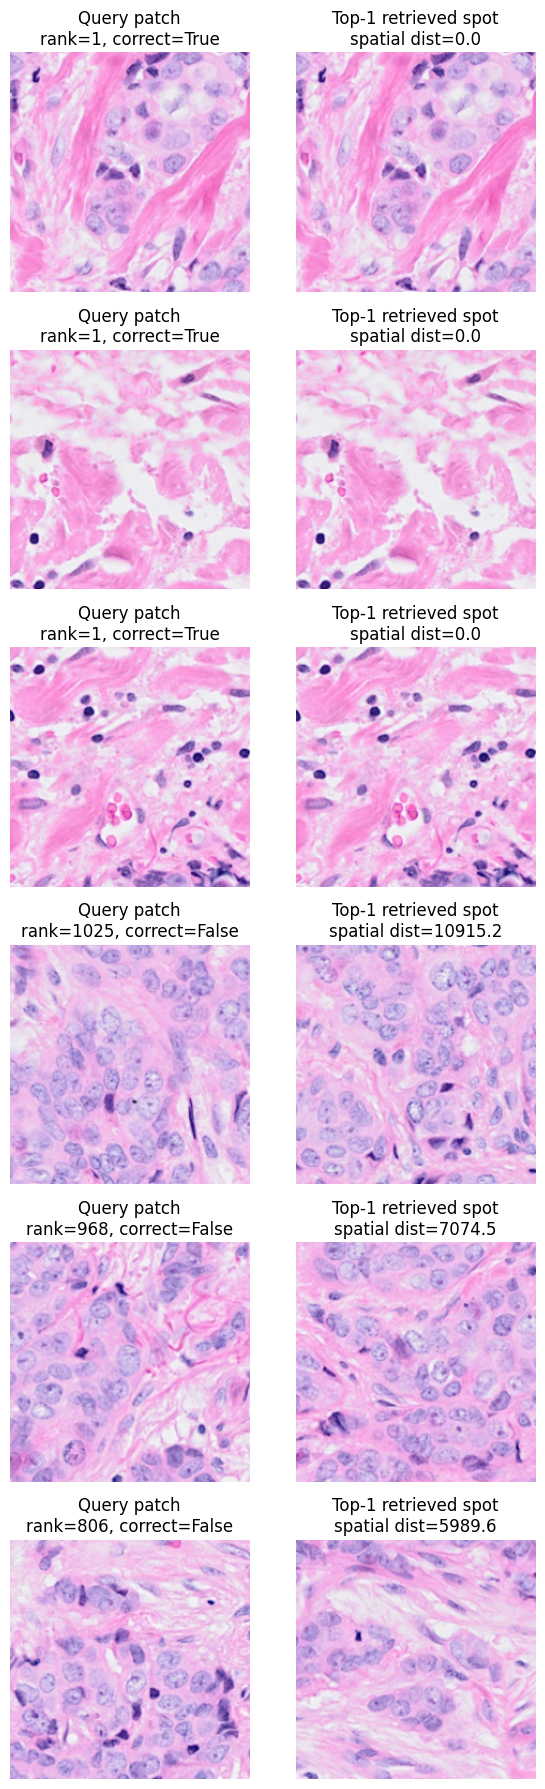

Saved retrieval patch examples: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_retrieval_patch_examples.png


In [14]:
# ============================================================
# Visualizing retrieved patch pairs
#
# For Image→Gene retrieval, the retrieved item is a gene profile,
# but because every gene profile still has an aligned H&E patch,
# I am visualizing:
#
#   query image patch
#   patch associated with top-1 retrieved gene spot
#
# This is useful for qualitative morphology inspection.
# ============================================================

import h5py

PATCH_H5_PATH = PROJECT_ROOT / "data" / "raw" / "hest" / "patches" / f"{SAMPLE_ID}.h5"
PATCH_RETRIEVAL_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_retrieval_patch_examples.png"

if PATCH_H5_PATH.exists():
    good_examples = i2g_examples[i2g_examples["top1_correct"]].head(3)
    bad_examples = i2g_examples[~i2g_examples["top1_correct"]].sort_values("true_rank", ascending=False).head(3)

    example_rows = pd.concat([good_examples, bad_examples], axis=0).reset_index(drop=True)

    if len(example_rows) > 0:
        with h5py.File(PATCH_H5_PATH, "r") as f:
            imgs = f["img"]

            n_examples = len(example_rows)
            fig, axes = plt.subplots(n_examples, 2, figsize=(6, 3 * n_examples))

            if n_examples == 1:
                axes = np.array([axes])

            for i, row in example_rows.iterrows():
                query_global_row = int(row["query_global_row"])
                retrieved_global_row = int(row["retrieved_global_row"])

                query_patch_index = int(metadata.iloc[query_global_row]["patch_index"])
                retrieved_patch_index = int(metadata.iloc[retrieved_global_row]["patch_index"])

                query_img = imgs[query_patch_index]
                retrieved_img = imgs[retrieved_patch_index]

                axes[i, 0].imshow(query_img)
                axes[i, 0].axis("off")
                axes[i, 0].set_title(
                    f"Query patch\nrank={int(row['true_rank'])}, correct={row['top1_correct']}"
                )

                axes[i, 1].imshow(retrieved_img)
                axes[i, 1].axis("off")
                axes[i, 1].set_title(
                    f"Top-1 retrieved spot\nspatial dist={row['spatial_distance_to_top1']:.1f}"
                )

            plt.tight_layout()
            plt.savefig(PATCH_RETRIEVAL_FIG_PATH, dpi=300, bbox_inches="tight")
            plt.show()

        print("Saved retrieval patch examples:", PATCH_RETRIEVAL_FIG_PATH)
    else:
        print("No examples available to visualize.")
else:
    print("Patch H5 file not found, skipping patch visualization:")
    print(PATCH_H5_PATH)

This figure gives me a qualitative look at what the retrieval model is doing, beyond just the numerical metrics.

Each row compares:

    Left:  Query H&E patch
    Right: Top-1 retrieved spot's corresponding H&E patch

For Image→Gene retrieval, the model is technically retrieving a gene-expression profile, but since every gene profile is linked to a spatial H&E patch, I can visualize the patch associated with the retrieved gene spot.

In [15]:
# ============================================================
# Final result summary
# ============================================================

test_row = retrieval_metrics_df[retrieval_metrics_df["split"] == "test"].iloc[0]

summary = {
    "sample_id": SAMPLE_ID,
    "n_test": int(test_row["n"]),
    "image_to_gene": {
        "Recall@1": float(test_row["image_to_gene_Recall@1"]),
        "Recall@5": float(test_row["image_to_gene_Recall@5"]),
        "Recall@10": float(test_row["image_to_gene_Recall@10"]),
        "MedianRank": float(test_row["image_to_gene_MedianRank"]),
        "MRR": float(test_row["image_to_gene_MRR"]),
    },
    "gene_to_image": {
        "Recall@1": float(test_row["gene_to_image_Recall@1"]),
        "Recall@5": float(test_row["gene_to_image_Recall@5"]),
        "Recall@10": float(test_row["gene_to_image_Recall@10"]),
        "MedianRank": float(test_row["gene_to_image_MedianRank"]),
        "MRR": float(test_row["gene_to_image_MRR"]),
    },
    "random_baseline": {
        "Recall@1": float(test_row["random_Recall@1"]),
        "Recall@5": float(test_row["random_Recall@5"]),
        "Recall@10": float(test_row["random_Recall@10"]),
    },
    "interpretation_note": (
        "Model retrieval should be compared against random Recall@K. "
        "For a test split of size N, random Recall@1 is approximately 1/N."
    ),
}

print(json.dumps(summary, indent=2))

SUMMARY_PATH = METRICS_DIR / f"{SAMPLE_ID}_retrieval_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nSaved retrieval summary:", SUMMARY_PATH)

{
  "sample_id": "TENX95",
  "n_test": 1130,
  "image_to_gene": {
    "Recall@1": 0.08584070796460178,
    "Recall@5": 0.2929203539823009,
    "Recall@10": 0.4150442477876106,
    "MedianRank": 17.0,
    "MRR": 0.19008870837581268
  },
  "gene_to_image": {
    "Recall@1": 0.08584070796460178,
    "Recall@5": 0.2743362831858407,
    "Recall@10": 0.384070796460177,
    "MedianRank": 17.0,
    "MRR": 0.18599352312226894
  },
  "random_baseline": {
    "Recall@1": 0.0008849557522123894,
    "Recall@5": 0.004424778761061947,
    "Recall@10": 0.008849557522123894
  },
  "interpretation_note": "Model retrieval should be compared against random Recall@K. For a test split of size N, random Recall@1 is approximately 1/N."
}

Saved retrieval summary: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_retrieval_summary.json


In [16]:
# ============================================================
# Final Notebook checklist
# ============================================================

checklist = {
    "retrieval_metrics_csv_exists": RETRIEVAL_METRICS_CSV_PATH.exists(),
    "retrieval_metrics_json_exists": RETRIEVAL_METRICS_JSON_PATH.exists(),
    "test_i2g_examples_exists": TEST_I2G_EXAMPLES_PATH.exists(),
    "test_g2i_examples_exists": TEST_G2I_EXAMPLES_PATH.exists(),
    "recall_bar_figure_exists": RECALL_BAR_FIG_PATH.exists(),
    "rank_distribution_figure_exists": RANK_DIST_FIG_PATH.exists(),
    "similarity_heatmap_exists": SIMILARITY_HEATMAP_PATH.exists(),
    "pca_figure_exists": PCA_FIG_PATH.exists(),
    "spatial_success_figure_exists": SPATIAL_SUCCESS_FIG_PATH.exists(),
    "summary_json_exists": SUMMARY_PATH.exists(),
    "test_metrics_has_rows": len(retrieval_metrics_df) == 3,
    "test_split_exists": "test" in retrieval_metrics_df["split"].values,
}

checklist_df = pd.DataFrame(
    [{"check": key, "passed": value} for key, value in checklist.items()]
)

display(checklist_df)

assert checklist_df["passed"].all(), "One or more Notebook 06 checks failed."

print("\nNotebook 06 completed successfully.")
print("\nKey outputs:")
print(RETRIEVAL_METRICS_CSV_PATH)
print(RECALL_BAR_FIG_PATH)
print(SIMILARITY_HEATMAP_PATH)
print(TEST_I2G_EXAMPLES_PATH)
print(TEST_G2I_EXAMPLES_PATH)

,check,passed
0,retrieval_metrics_csv_exists,True
1,retrieval_metrics_json_exists,True
2,test_i2g_examples_exists,True
3,test_g2i_examples_exists,True
4,recall_bar_figure_exists,True
5,rank_distribution_figure_exists,True
6,similarity_heatmap_exists,True
7,pca_figure_exists,True
8,spatial_success_figure_exists,True
9,summary_json_exists,True



Notebook 06 completed successfully.

Key outputs:
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_retrieval_metrics_by_split.csv
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_retrieval_recall_bar.png
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_test_similarity_heatmap.png
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_test_image_to_gene_retrieval_examples.csv
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_test_gene_to_image_retrieval_examples.csv
